# SSB modulation CH3 phase test

Bench wiring:

- AWG CH1 -> RF source I
- AWG CH3+ -> RF source Q
- AWG CH1 marker 1 -> Alazar trigger
- Alazar CHB -> measured IF / receiver output
- SGS100A RF source: 5.9 GHz, 0 dBm, external IQ on

This notebook sweeps the AWG CH3 phase and plots the Alazar CHB FFT amplitude
at the 50 MHz IF. Use it as a first-pass SSB calibration test.

In [24]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo = Path.cwd()
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

from QAWG import AWGAlazar, ExperimentProgram, MHz, ValuesSweep, ns, us
from QAWG.instrument import RohdeSchwarzSGS100A

## Hardware and sweep parameters

In [50]:
AWG_RESOURCE = "TCPIP0::192.168.10.171::inst0::INSTR"
SGS100A_ADDRESS = "192.168.10.90"

AWG_SAMPLE_RATE_HZ = 2.5e9
ALAZAR_SAMPLE_RATE_HZ = 1e9

SGS_FREQUENCY_HZ = 5.9e9
SGS_POWER_DBM = 0.0
IF_FREQUENCY_HZ = 50 * MHz

I_AWG_CH = 1
Q_AWG_CH = 3
MARKER_CH = 1
ADC_CHANNEL = "CHB"

CHANNEL_AMPLITUDE_VPP = 0.5
IQ_GAIN_FRACTION = 0.4
PULSE_LENGTH = 2.0 * us
EDGE_SIGMA = 20 * ns
MARKER_PADDING = 200 * ns
TRIGGER_DELAY = 200 * ns
ACQUIRE_LENGTH = 2.5 * us
INTEGRATE_TIME = 1 * us
FINAL_DELAY = 1.0 * us

# FFT only this stable part of the captured record.
# The late step near the end creates a large low-frequency FFT artifact.
FFT_START_NS = 300.0
FFT_STOP_NS = 2100.0

# First-pass CH3 phase sweep. Refine around the best/minimum phase later.
CH3_PHASE_DEG = np.linspace(-180.0, 180.0, 19)

N_AVERAGE = 1000
TRIGGER_LEVEL = 140
ALAZAR_TIMEOUT_MS = 60_000
SGS_SETTLE_S = 0.2

## Program definition

In [51]:
class SSBPhaseSweepProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "i",
            ch=cfg["i_awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_gen(
            "q",
            ch=cfg["q_awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["acquire_length"],
            demod_freq=cfg["if_frequency_hz"],
            waveform_ch=cfg["i_awg_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["integrate_time"],
        )

        q_phase = self.add_sweep(
            "q_phase_rad",
            ValuesSweep(np.deg2rad(cfg["q_phase_deg"])),
        )
        self.add_pulse(
            "i_tone",
            gen="i",
            style="gaussian_square",
            length=cfg["pulse_length"],
            edge_sigma=cfg["edge_sigma"],
            frequency=cfg["if_frequency_hz"],
            phase=0.0,
            gain=cfg["iq_gain_fraction"],
            readout=True,
        )
        self.add_pulse(
            "q_tone",
            gen="q",
            style="gaussian_square",
            length=cfg["pulse_length"],
            edge_sigma=cfg["edge_sigma"],
            frequency=cfg["if_frequency_hz"],
            phase=q_phase,
            gain=cfg["iq_gain_fraction"],
        )

    def _body(self, cfg):
        self.play("i_tone", at=0.0)
        self.play("q_tone", at=0.0)
        self.trigger("ro", trigger_delay=cfg["trigger_delay"])


def fft_amplitude_at(
    time_s,
    trace_v,
    target_hz,
    *,
    start_s=300e-9,
    stop_s=2100e-9,
):
    start = int(np.searchsorted(time_s, start_s))
    stop = int(np.searchsorted(time_s, stop_s))
    if stop <= start + 8:
        raise ValueError("FFT window is too short")
    values = trace_v[start:stop] - np.mean(trace_v[start:stop])
    window = np.hanning(values.size)
    coherent_gain = np.sum(window) / window.size
    spectrum_v = (
        2.0
        * np.abs(np.fft.rfft(values * window))
        / (values.size * coherent_gain)
    )
    frequency_hz = np.fft.rfftfreq(values.size, d=time_s[1] - time_s[0])
    target_index = int(np.argmin(np.abs(frequency_hz - target_hz)))
    time_window_s = time_s[start:stop]
    return float(spectrum_v[target_index]), frequency_hz, spectrum_v, time_window_s, values


## Connect SGS100A, AWG, and Alazar

In [52]:
sgs = RohdeSchwarzSGS100A(SGS100A_ADDRESS)
sgs.frequency = SGS_FREQUENCY_HZ
sgs.power = SGS_POWER_DBM
sgs.IQ_state = "on"
sgs.pulsemod_state = "off"
sgs.on()
time.sleep(SGS_SETTLE_S)

print("SGS:", sgs.idn())
print(f"SGS frequency: {sgs.frequency / 1e9:.9f} GHz")
print(f"SGS power: {sgs.power:.3f} dBm")
print("SGS IQ:", sgs.IQ_state)
print("SGS RF output:", sgs.status)
print("SGS error:", sgs.check_error())

experiment = AWGAlazar.connect(
    AWG_RESOURCE,
    awg_sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    alazar_sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ,
    acquire_window_s=ACQUIRE_LENGTH,
    trigger_slope="rising",
    trigger_level=TRIGGER_LEVEL,
    timeout_ms=ALAZAR_TIMEOUT_MS,
    use_external_10mhz_reference=True,
    adc_channel=ADC_CHANNEL,
    tone_frequency_hz=IF_FREQUENCY_HZ,
    trigger_delay_s=TRIGGER_DELAY,
    integrate_time_s=INTEGRATE_TIME,
    moving_average_time_s=20e-9,
    baseline_time_s=100e-9,
)

print("AWG:", experiment.awg.identify())
print("Alazar channel:", experiment.adc_channel_name)

Connected to: Rohde&Schwarz,SGS100A,1416.0505k02/112369,4.2.76.0-4.30.046.295
SGS: Rohde&Schwarz,SGS100A,1416.0505k02/112369,4.2.76.0-4.30.046.295
SGS frequency: 5.900000000 GHz
SGS power: 0.000 dBm
SGS IQ: on
SGS RF output: on
Instrument Status: 0,"No error"
SGS error: 0,"No error"
AWG: TEKTRONIX,AWG5208,B030598,FV:6.6.0131.0
Alazar channel: CHB


## Compile and upload CH3 phase sweep

In [53]:
cfg = {
    "i_awg_ch": I_AWG_CH,
    "q_awg_ch": Q_AWG_CH,
    "marker_ch": MARKER_CH,
    "adc_channel": ADC_CHANNEL,
    "channel_amplitude_vpp": CHANNEL_AMPLITUDE_VPP,
    "iq_gain_fraction": IQ_GAIN_FRACTION,
    "if_frequency_hz": IF_FREQUENCY_HZ,
    "q_phase_deg": CH3_PHASE_DEG,
    "pulse_length": PULSE_LENGTH,
    "edge_sigma": EDGE_SIGMA,
    "marker_padding": MARKER_PADDING,
    "trigger_delay": TRIGGER_DELAY,
    "acquire_length": ACQUIRE_LENGTH,
    "integrate_time": INTEGRATE_TIME,
}

program = SSBPhaseSweepProgram(
    cfg,
    name="ssb_ch3_phase_sweep",
    final_delay_s=FINAL_DELAY,
)
program.REMOVE_DC_OFFSET = True
compiled = program.compile(hardware=experiment)
sequence_name = compiled.upload()

marker_samples = np.flatnonzero(compiled.marker_waveforms[0])
marker_start_ns = marker_samples[0] / AWG_SAMPLE_RATE_HZ / ns
marker_stop_ns = (marker_samples[-1] + 1) / AWG_SAMPLE_RATE_HZ / ns

print("Sequence:", sequence_name)
print("Steps:", compiled.number_of_sequence_steps)
print(f"I/Q channels: AWG CH{I_AWG_CH} / CH{Q_AWG_CH}+")
print(f"Marker: AWG CH{MARKER_CH} marker 1")
print(f"Marker window: {marker_start_ns:.3f} to {marker_stop_ns:.3f} ns")
print("AWG error:", experiment.awg.error())

Sequence: ssb_ch3_phase_sweep
Steps: 19
I/Q channels: AWG CH1 / CH3+
Marker: AWG CH1 marker 1
Marker window: 0.000 to 2400.000 ns
AWG error: 0,"No error"


## Acquire phase sweep and FFT

## Plot

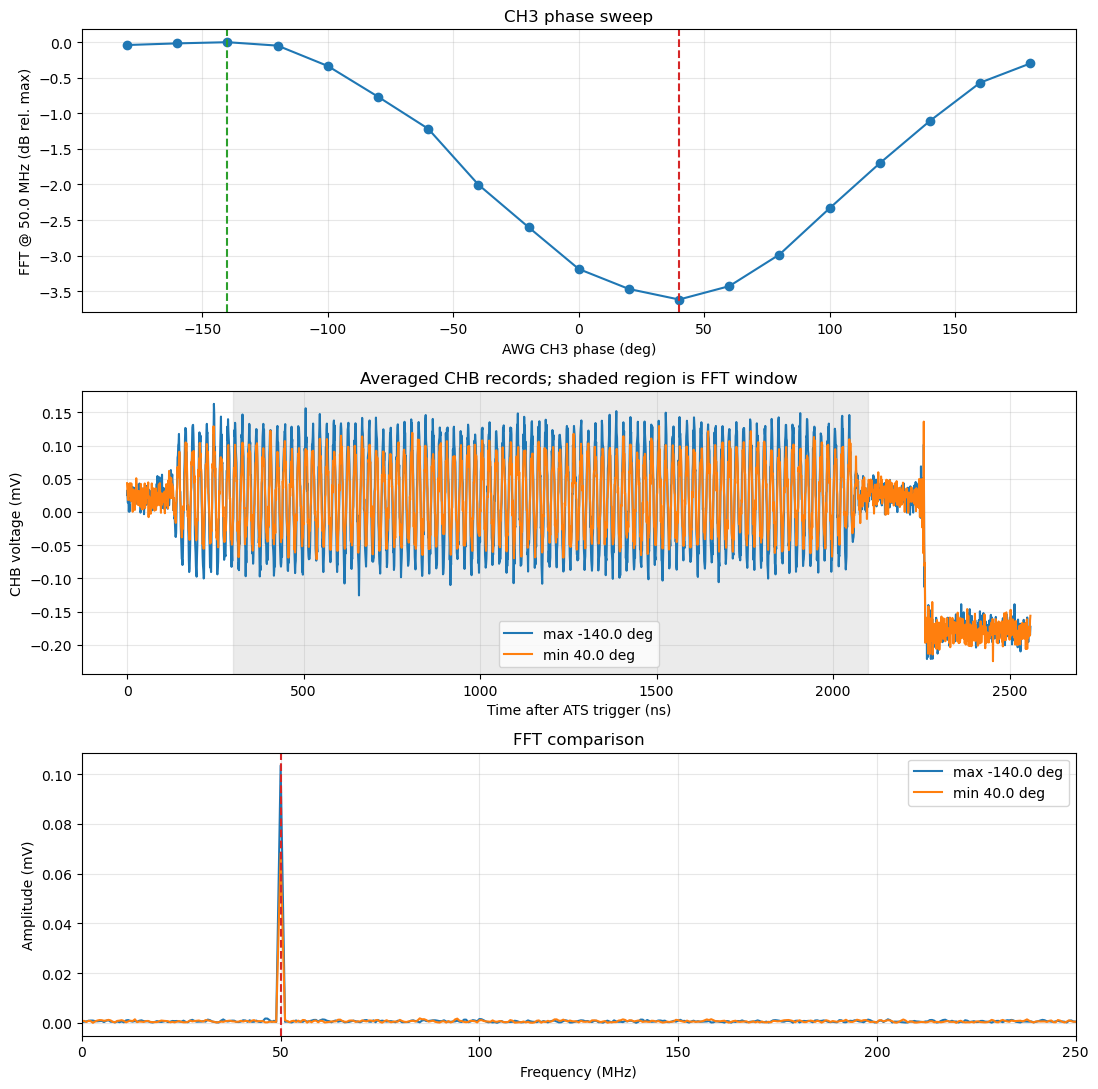

In [55]:
fig, axes = plt.subplots(3, 1, figsize=(11, 11))

fft_at_if_db = 20.0 * np.log10(
    np.maximum(fft_at_if_v, np.finfo(float).tiny)
    / np.max(np.maximum(fft_at_if_v, np.finfo(float).tiny))
)

axes[0].plot(phase_deg, fft_at_if_db, "o-")
axes[0].axvline(phase_deg[best_index], color="tab:green", linestyle="--")
axes[0].axvline(phase_deg[worst_index], color="tab:red", linestyle="--")
axes[0].set_xlabel("AWG CH3 phase (deg)")
axes[0].set_ylabel(f"FFT @ {IF_FREQUENCY_HZ / MHz:.1f} MHz (dB rel. max)")
axes[0].set_title("CH3 phase sweep")
axes[0].grid(True, alpha=0.3)

axes[1].plot(raw_time_s / ns, average_records_v[best_index] * 1e3)
axes[1].plot(raw_time_s / ns, average_records_v[worst_index] * 1e3)
axes[1].axvspan(FFT_START_NS, FFT_STOP_NS, color="tab:gray", alpha=0.15)
axes[1].set_xlabel("Time after ATS trigger (ns)")
axes[1].set_ylabel("CHB voltage (mV)")
axes[1].set_title("Averaged CHB records; shaded region is FFT window")
axes[1].legend(
    [
        f"max {phase_deg[best_index]:.1f} deg",
        f"min {phase_deg[worst_index]:.1f} deg",
    ]
)
axes[1].grid(True, alpha=0.3)

axes[2].plot(
    frequency_hz / MHz,
    spectra[best_index] * 1e3,
    label=f"max {phase_deg[best_index]:.1f} deg",
)
axes[2].plot(
    frequency_hz / MHz,
    spectra[worst_index] * 1e3,
    label=f"min {phase_deg[worst_index]:.1f} deg",
)
axes[2].axvline(IF_FREQUENCY_HZ / MHz, color="tab:red", linestyle="--")
axes[2].set_xlim(0, 250)
axes[2].set_xlabel("Frequency (MHz)")
axes[2].set_ylabel("Amplitude (mV)")
axes[2].set_title("FFT comparison")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2D CH3 phase x gain heatmap

Run this after the 1D phase sweep. It uploads a new 2D sequence that sweeps CH3 phase and CH3 gain, then plots FFT@50MHz in dB relative to the largest point. The best cancellation point is marked in red.

## Resonator sideband verification

This copies the spectroscopy idea from `Qawgdemo.ipynb`, but drives the RF source with both AWG I/Q channels. It uses the heatmap result (`best_phase_deg`, `best_q_gain`) and checks which RF mapping couples to the resonator:

- Upper-sideband hypothesis: `RF = SGS + IF`, so `SGS = RF - IF`
- Lower-sideband hypothesis: `RF = SGS - IF`, so `SGS = RF + IF`

If the resonator is connected and narrowband, the stronger spectroscopy trace tells you which sideband is actually reaching the resonator.

Uploading SSB resonator readout...
CH3 phase: -119.99999999999999
CH3 gain fraction: 0.37777777777777777
AWG error: 0,"No error"
USB hypothesis 001/41: drive=5.800000000 GHz, sgs=5.750000000 GHz, |IQ|=0.006970 mV, peak=0.124964 mV
USB hypothesis 002/41: drive=5.805000000 GHz, sgs=5.755000000 GHz, |IQ|=0.009463 mV, peak=0.125999 mV
USB hypothesis 003/41: drive=5.810000000 GHz, sgs=5.760000000 GHz, |IQ|=0.014236 mV, peak=0.117476 mV
USB hypothesis 004/41: drive=5.815000000 GHz, sgs=5.765000000 GHz, |IQ|=0.018786 mV, peak=0.121092 mV
USB hypothesis 005/41: drive=5.820000000 GHz, sgs=5.770000000 GHz, |IQ|=0.018744 mV, peak=0.137808 mV
USB hypothesis 006/41: drive=5.825000000 GHz, sgs=5.775000000 GHz, |IQ|=0.015739 mV, peak=0.123168 mV
USB hypothesis 007/41: drive=5.830000000 GHz, sgs=5.780000000 GHz, |IQ|=0.020003 mV, peak=0.123435 mV
USB hypothesis 008/41: drive=5.835000000 GHz, sgs=5.785000000 GHz, |IQ|=0.034976 mV, peak=0.127071 mV
USB hypothesis 009/41: drive=5.840000000 GHz, sgs=5.790

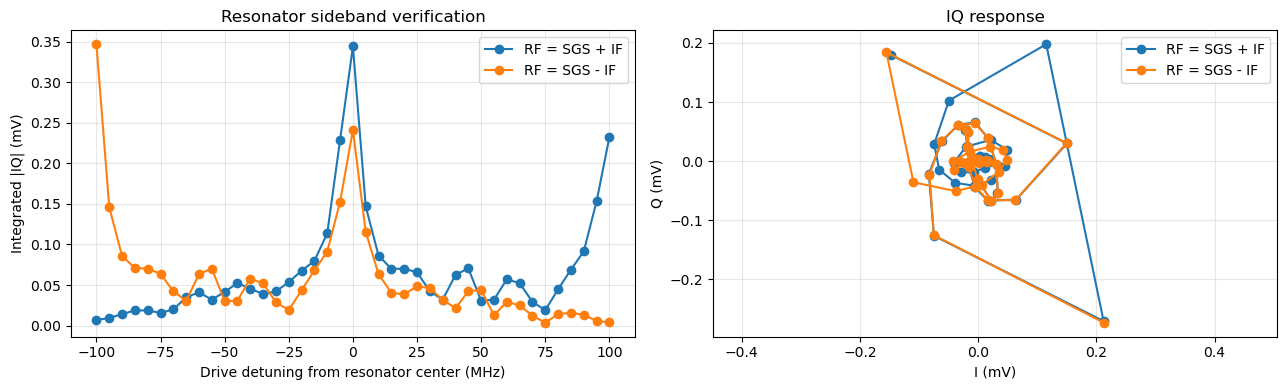

In [48]:
class SSBResonatorReadoutProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "i",
            ch=cfg["i_awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_gen(
            "q",
            ch=cfg["q_awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["pulse_length"],
            demod_freq=cfg["if_frequency_hz"],
            waveform_ch=cfg["i_awg_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["integrate_time"],
        )
        self.add_pulse(
            "i_readout",
            gen="i",
            style="gaussian_square",
            length=cfg["pulse_length"],
            edge_sigma=cfg["edge_sigma"],
            frequency=cfg["if_frequency_hz"],
            phase=0.0,
            gain=cfg["i_gain_fraction"],
            readout=True,
        )
        self.add_pulse(
            "q_readout",
            gen="q",
            style="gaussian_square",
            length=cfg["pulse_length"],
            edge_sigma=cfg["edge_sigma"],
            frequency=cfg["if_frequency_hz"],
            phase=np.deg2rad(cfg["q_phase_deg"]),
            gain=cfg["q_gain_fraction"],
        )

    def _body(self, cfg):
        self.play("i_readout", at=0.0)
        self.play("q_readout", at=0.0)
        self.trigger("ro", trigger_delay=cfg["trigger_delay"])


# Use the heatmap minimum if it has been measured. Adjust the fallback values
# if you want to test a known setting without rerunning the heatmap.
SSB_Q_PHASE_DEG = float(best_phase_deg) if "best_phase_deg" in globals() else -20.0
SSB_Q_GAIN_FRACTION = float(best_q_gain) if "best_q_gain" in globals() else 0.95

# Set this to your resonator frequency. The default follows the current SGS setup.
RESONATOR_RF_CENTER_HZ = 5.9e9
RESONATOR_SPAN_HZ = 150 * MHz
RESONATOR_POINTS = 41
RESONATOR_N_AVERAGE = 500
SGS_SETTLE_S = 0.05

resonator_drive_hz = np.linspace(5.8e9, 6e9, RESONATOR_POINTS)


ssb_resonator_cfg = {
    "i_awg_ch": I_AWG_CH,
    "q_awg_ch": Q_AWG_CH,
    "marker_ch": MARKER_CH,
    "adc_channel": ADC_CHANNEL,
    "channel_amplitude_vpp": CHANNEL_AMPLITUDE_VPP,
    "i_gain_fraction": IQ_GAIN_FRACTION,
    "q_gain_fraction": SSB_Q_GAIN_FRACTION,
    "q_phase_deg": SSB_Q_PHASE_DEG,
    "if_frequency_hz": IF_FREQUENCY_HZ,
    "pulse_length": PULSE_LENGTH,
    "edge_sigma": EDGE_SIGMA,
    "marker_padding": MARKER_PADDING,
    "trigger_delay": TRIGGER_DELAY,
    "integrate_time": INTEGRATE_TIME,
}

ssb_resonator_program = SSBResonatorReadoutProgram(
    ssb_resonator_cfg,
    name="ssb_resonator_verify",
    final_delay_s=FINAL_DELAY,
)
ssb_resonator_program.REMOVE_DC_OFFSET = True
ssb_resonator_compiled = ssb_resonator_program.compile(hardware=experiment)
print("Uploading SSB resonator readout...")
ssb_resonator_compiled.upload()
print("CH3 phase:", SSB_Q_PHASE_DEG)
print("CH3 gain fraction:", SSB_Q_GAIN_FRACTION)
print("AWG error:", experiment.awg.error())


def run_resonator_sideband_sweep(sideband_sign, label):
    # sideband_sign=+1 means RF = SGS + IF. sideband_sign=-1 means RF = SGS - IF.
    sgs_frequency_hz = resonator_drive_hz - sideband_sign * IF_FREQUENCY_HZ
    iq = np.empty(resonator_drive_hz.size, dtype=np.complex128)
    peak_mv = np.empty(resonator_drive_hz.size, dtype=float)

    for index, (drive_hz, sgs_hz) in enumerate(zip(resonator_drive_hz, sgs_frequency_hz)):
        sgs.frequency = float(sgs_hz)
        time.sleep(SGS_SETTLE_S)
        result = ssb_resonator_compiled.acquire(
            n_average=RESONATOR_N_AVERAGE,
                )
        iq[index] = result.iq_average("ro")[0]
        avg_trace = result.iq_trace_average("ro")[0]
        peak_mv[index] = np.max(np.abs(avg_trace)) * 1e3
        print(
            f"{label} {index + 1:03d}/{resonator_drive_hz.size}: "
            f"drive={drive_hz / 1e9:.9f} GHz, "
            f"sgs={sgs_hz / 1e9:.9f} GHz, "
            f"|IQ|={abs(iq[index]) * 1e3:.6f} mV, "
            f"peak={peak_mv[index]:.6f} mV"
        )
    return sgs_frequency_hz, iq, peak_mv

upper_sgs_hz, upper_iq, upper_peak_mv = run_resonator_sideband_sweep(+1, "USB hypothesis")
lower_sgs_hz, lower_iq, lower_peak_mv = run_resonator_sideband_sweep(-1, "LSB hypothesis")

upper_amp_mv = np.abs(upper_iq) * 1e3
lower_amp_mv = np.abs(lower_iq) * 1e3
upper_best_index = int(np.argmax(upper_amp_mv))
lower_best_index = int(np.argmax(lower_amp_mv))

print()
print(
    f"USB hypothesis max |IQ| = {upper_amp_mv[upper_best_index]:.6f} mV "
    f"at drive {resonator_drive_hz[upper_best_index] / 1e9:.9f} GHz"
)
print(
    f"LSB hypothesis max |IQ| = {lower_amp_mv[lower_best_index]:.6f} mV "
    f"at drive {resonator_drive_hz[lower_best_index] / 1e9:.9f} GHz"
)
print(
    "USB/LSB max ratio = "
    f"{20 * np.log10(max(upper_amp_mv[upper_best_index], np.finfo(float).tiny) / max(lower_amp_mv[lower_best_index], np.finfo(float).tiny)):.2f} dB"
)
print("SGS error:", sgs.check_error())
print("AWG error:", experiment.awg.error())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
detuning_mhz = (resonator_drive_hz - RESONATOR_RF_CENTER_HZ) / MHz

axes[0].plot(detuning_mhz, upper_amp_mv, "o-", label="RF = SGS + IF")
axes[0].plot(detuning_mhz, lower_amp_mv, "o-", label="RF = SGS - IF")
axes[0].set_xlabel("Drive detuning from resonator center (MHz)")
axes[0].set_ylabel("Integrated |IQ| (mV)")
axes[0].set_title("Resonator sideband verification")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(upper_iq.real * 1e3, upper_iq.imag * 1e3, "o-", label="RF = SGS + IF")
axes[1].plot(lower_iq.real * 1e3, lower_iq.imag * 1e3, "o-", label="RF = SGS - IF")
axes[1].set_xlabel("I (mV)")
axes[1].set_ylabel("Q (mV)")
axes[1].set_title("IQ response")
axes[1].axis("equal")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## Single-shot: I-only vs SSB

This compares two single-shot clouds at the same resonator/on-resonance setting:

- `CH3 gain = 0`: I-only, no SSB correction
- `CH3 gain = best`: SSB setting from the heatmap/resonator verification

Run this after the heatmap and after setting the successful `SSB_Q_PHASE_DEG` convention.

In [49]:
SINGLE_SHOT_N_AVERAGE = 3000
SINGLE_SHOT_SIDEBAND_SIGN = +1  # +1: RF = SGS + IF, -1: RF = SGS - IF
SINGLE_SHOT_SETTLE_S = 0.05

# Use current successful values if they exist. If you manually found upper sideband
# by adding 180 deg, set SSB_Q_PHASE_DEG above before running this cell.
single_shot_phase_deg = float(SSB_Q_PHASE_DEG) if "SSB_Q_PHASE_DEG" in globals() else float(best_phase_deg)
single_shot_best_gain = float(SSB_Q_GAIN_FRACTION) if "SSB_Q_GAIN_FRACTION" in globals() else float(best_q_gain)

single_shot_sgs_hz = RESONATOR_RF_CENTER_HZ - SINGLE_SHOT_SIDEBAND_SIGN * IF_FREQUENCY_HZ
sgs.frequency = float(single_shot_sgs_hz)
time.sleep(SINGLE_SHOT_SETTLE_S)
print(f"Single-shot SGS frequency: {sgs.frequency / 1e9:.9f} GHz")
print(
    "On-resonance mapping: "
    + ("RF = SGS + IF" if SINGLE_SHOT_SIDEBAND_SIGN > 0 else "RF = SGS - IF")
)
print(f"SSB CH3 phase: {single_shot_phase_deg:.3f} deg")
print(f"SSB CH3 gain: {single_shot_best_gain:.6f}")


def acquire_single_shot_cloud(q_gain_fraction, label):
    cfg = {
        "i_awg_ch": I_AWG_CH,
        "q_awg_ch": Q_AWG_CH,
        "marker_ch": MARKER_CH,
        "adc_channel": ADC_CHANNEL,
        "channel_amplitude_vpp": CHANNEL_AMPLITUDE_VPP,
        "i_gain_fraction": IQ_GAIN_FRACTION,
        "q_gain_fraction": float(q_gain_fraction),
        "q_phase_deg": single_shot_phase_deg,
        "if_frequency_hz": IF_FREQUENCY_HZ,
        "pulse_length": PULSE_LENGTH,
        "edge_sigma": EDGE_SIGMA,
        "marker_padding": MARKER_PADDING,
        "trigger_delay": TRIGGER_DELAY,
        "integrate_time": INTEGRATE_TIME,
    }
    program = SSBResonatorReadoutProgram(
        cfg,
        name=f"single_shot_{label.replace(' ', '_').replace('/', '_')}",
        final_delay_s=FINAL_DELAY,
    )
    program.REMOVE_DC_OFFSET = True
    compiled_single = program.compile(hardware=experiment)
    print(f"Uploading {label} sequence...")
    compiled_single.upload()
    result = compiled_single.acquire(
        n_average=SINGLE_SHOT_N_AVERAGE,
        )
    shots = result.shots("ro")[:, 0]
    avg = np.mean(shots)
    std = np.std(shots)
    print(
        f"{label}: mean |IQ|={abs(avg) * 1e3:.6f} mV, "
        f"shot std={std * 1e3:.6f} mV"
    )
    return shots, result

shots_i_only, result_i_only = acquire_single_shot_cloud(0.0, "CH3 gain 0 / I-only")
shots_ssb, result_ssb = acquire_single_shot_cloud(single_shot_best_gain, "CH3 best gain / SSB")

mean_i_only = np.mean(shots_i_only)
mean_ssb = np.mean(shots_ssb)
ratio_db = 20.0 * np.log10(
    max(abs(mean_ssb), np.finfo(float).tiny)
    / max(abs(mean_i_only), np.finfo(float).tiny)
)
print()
print(f"I-only mean: I={mean_i_only.real * 1e3:.6f} mV, Q={mean_i_only.imag * 1e3:.6f} mV, |IQ|={abs(mean_i_only) * 1e3:.6f} mV")
print(f"SSB mean:    I={mean_ssb.real * 1e3:.6f} mV, Q={mean_ssb.imag * 1e3:.6f} mV, |IQ|={abs(mean_ssb) * 1e3:.6f} mV")
print(f"SSB / I-only mean amplitude ratio: {ratio_db:.2f} dB")
print("SGS error:", sgs.check_error())
print("AWG error:", experiment.awg.error())

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
clouds = [
    (shots_i_only, mean_i_only, "CH3 gain = 0 / I-only"),
    (shots_ssb, mean_ssb, "CH3 best gain / SSB"),
]
for ax, (shots, mean, title) in zip(axes, clouds):
    ax.scatter(shots.real * 1e3, shots.imag * 1e3, s=6, alpha=0.25)
    ax.plot(mean.real * 1e3, mean.imag * 1e3, "rx", markersize=12, markeredgewidth=2)
    ax.set_title(title)
    ax.set_xlabel("I (mV)")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Q (mV)")
axes[0].axis("equal")
axes[1].axis("equal")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax.scatter(shots_i_only.real * 1e3, shots_i_only.imag * 1e3, s=6, alpha=0.18, label="CH3 gain = 0")
ax.scatter(shots_ssb.real * 1e3, shots_ssb.imag * 1e3, s=6, alpha=0.18, label="SSB best gain")
ax.plot(mean_i_only.real * 1e3, mean_i_only.imag * 1e3, "bx", markersize=12, markeredgewidth=2)
ax.plot(mean_ssb.real * 1e3, mean_ssb.imag * 1e3, "rx", markersize=12, markeredgewidth=2)
ax.set_xlabel("I (mV)")
ax.set_ylabel("Q (mV)")
ax.set_title("Single-shot overlay")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


Single-shot SGS frequency: 5.850000000 GHz
On-resonance mapping: RF = SGS + IF
SSB CH3 phase: -120.000 deg
SSB CH3 gain: 0.377778
Uploading CH3 gain 0 / I-only sequence...
CH3 gain 0 / I-only: mean |IQ|=0.072507 mV, shot std=0.025467 mV
Uploading CH3 best gain / SSB sequence...
CH3 best gain / SSB: mean |IQ|=0.343271 mV, shot std=0.040899 mV

I-only mean: I=0.068954 mV, Q=-0.022420 mV, |IQ|=0.072507 mV
SSB mean:    I=0.208737 mV, Q=-0.272514 mV, |IQ|=0.343271 mV
SSB / I-only mean amplitude ratio: 13.51 dB
Instrument Status: 0,"No error"
SGS error: 0,"No error"
AWG error: 0,"No error"


RuntimeError: set_aspect(..., adjustable='datalim') or axis('equal') are not allowed when both axes are shared.  Try set_aspect(..., adjustable='box').

Error in callback <function _draw_all_if_interactive at 0x0000024839DF7240> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: set_aspect(..., adjustable='datalim') or axis('equal') are not allowed when both axes are shared.  Try set_aspect(..., adjustable='box').

RuntimeError: set_aspect(..., adjustable='datalim') or axis('equal') are not allowed when both axes are shared.  Try set_aspect(..., adjustable='box').

<Figure size 1200x500 with 2 Axes>

## Calibration note

This phase sweep is a first-pass test. Alazar CHB measures a real IF waveform,
so a normal FFT magnitude at 50 MHz does not by itself distinguish the RF upper
sideband from the RF lower sideband.

For proper SSB calibration:

1. Sweep CH3 phase and find the minimum image response.
2. Sweep CH3 gain/amplitude around that phase.
3. Do a 2D phase x gain sweep and minimize image leakage.
4. Use a spectrum analyzer, a second IQ receiver/downconverter, or a known
   narrowband resonator response to separately measure wanted sideband and
   image sideband.

## Close VISA sessions

In [8]:
experiment.close()
sgs.close()

Disconnecting from TCPIP0::192.168.10.90::inst0::INSTR
